In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt



In [2]:
#Skift working dir til hvor dataen er - if statement for at undgå at gå længere og længere tilbage


In [3]:
ds_sim = xr.open_dataset("simulation.nc")
ds_lab = xr.open_dataset("demodulated_dataset.nc")
ds_lab['adc_timestamp'] = ds_lab['adc_timestamp']*1e9


In [4]:
def weighting(data):
    weights_I = np.abs(
        data.I_ground.mean("sample") - data.I_excited.mean("sample")
    ) / np.var(data.I_ground.mean("sample") - data.I_excited.mean("sample"))

    weights_Q = np.abs(
        data.Q_ground.mean("sample") - data.Q_excited.mean("sample")
    ) / np.var(data.Q_ground.mean("sample") - data.Q_excited.mean("sample"))

    # Normalize the integration to give same units
    weights_I *= len(weights_I) / weights_I.sum()
    weights_Q *= len(weights_Q) / weights_Q.sum()

    data["I_ground"] *= weights_I
    data["I_excited"] *= weights_I
    data["Q_ground"] *= weights_Q
    data["Q_excited"] *= weights_Q

    return data

In [5]:
times = ds_sim.adc_timestamp.to_numpy()

ds_sim = weighting(ds_sim)

I_excited = ds_sim.I_excited.to_numpy()
I_ground = ds_sim.I_ground.to_numpy()

Q_excited = ds_sim.Q_excited.to_numpy()
Q_ground = ds_sim.Q_ground.to_numpy()


label0 = np.zeros(500)
label1 = np.ones(500)
labels_sim = np.concatenate((label0, label1), axis = 0)

excited = np.stack((I_excited, Q_excited), axis = 2)
ground = np.stack((I_ground, Q_ground), axis = 2)
df_sim = np.concatenate((ground, excited), axis = 0)

In [6]:
input_train, input_val, truth_train, truth_val = train_test_split(df_sim, labels_sim, test_size=0.25, random_state=23662741)

In [7]:
def integrate_simp(times, vals):
    pos = 0
    t0 = 0
    v0 = 0
    outp = [ ]
    for t,v in zip(times,vals):
        deltat = t - t0
        pos += deltat * v0
        outp.append( pos )
        t0 = t
        v0 = v
    return outp

In [8]:
def integrate(times, vals):

    big_outp = np.zeros_like(vals[0])
    outp = np.array([])

    for i in range(len(vals)):
        pos = 0
        t0 = 0
        v0 = 0
        outp = np.array([ ])

        for t,v in zip(times,vals[i]):
            deltat = t - t0
            pos += deltat * v0
            outp = np.append(outp,pos)
            t0 = t
            v0 = v
        
        big_outp = np.vstack((big_outp, outp))

    big_outp = np.delete(big_outp, 0, axis = 0)
    return big_outp

In [9]:
intI_excited = integrate(times, I_excited)
max = np.max(intI_excited)
intI_excited = intI_excited/max
intI_ground = integrate(times, I_ground)
intI_ground = intI_ground/max

intQ_excited = integrate(times, Q_excited)
max = np.max(intQ_excited)
intQ_excited = intQ_excited/max
intQ_ground = integrate(times, Q_ground)
intQ_ground = intQ_ground/max

intexcited = np.stack((intI_excited, intQ_excited), axis = 2)
intground = np.stack((intI_ground, intQ_ground), axis = 2)
intdf_sim = np.concatenate((intground, intexcited), axis = 0)
intdf_sim = intdf_sim.transpose(0, 2, 1)

In [59]:
print(len(intI_excited))

500


Text(0, 0.5, 'Q')

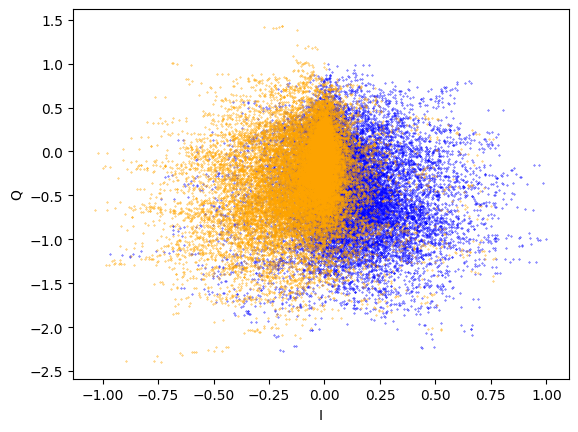

In [67]:
plt.scatter(intI_excited, intQ_excited, c = 'b', s = 0.1)
plt.scatter(intI_ground, intQ_ground, c = 'orange', s = 0.1)
plt.xlabel('I')
plt.ylabel('Q')

In [10]:
intdf_sim.shape

(1000, 2, 61)

In [11]:
from sklearn.cluster import KMeans
from tslearn.clustering import TimeSeriesKMeans, KShape
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesScalerMinMax
from tslearn.metrics import dtw


In [12]:
X_train, X_test, y_train, y_test = train_test_split(intdf_sim, labels_sim, test_size=0.25, random_state=23662741)
X_train_scaled = TimeSeriesScalerMinMax().fit_transform(X_train)

print(X_train_scaled)

[[[0. 0. 0. ... 1. 1. 1.]
  [0. 1. 1. ... 0. 0. 0.]]

 [[0. 1. 1. ... 1. 1. 1.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 1. 1. ... 1. 1. 1.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 1. 1. ... 1. 1. 1.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 1. 1. ... 0. 0. 0.]
  [0. 0. 0. ... 1. 1. 1.]]

 [[0. 1. 1. ... 1. 1. 1.]
  [0. 0. 0. ... 0. 0. 0.]]]


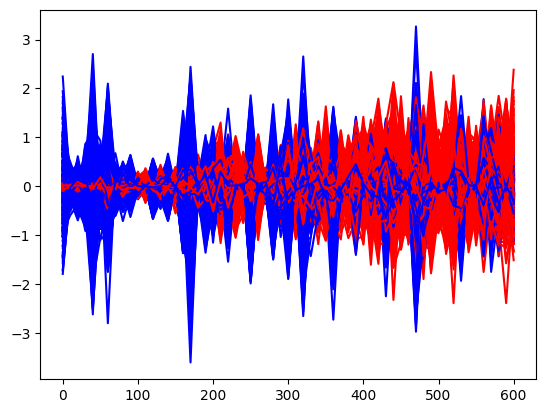

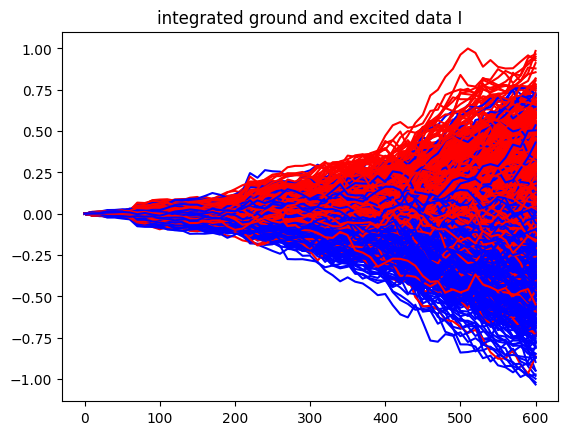

In [13]:
# plot the integrated data as a function if time
for i, value in enumerate(I_excited):
    plt.plot(times, I_excited[i], label = 'I_excited', color = 'red')
    plt.plot(times, Q_excited[i], label = 'Q_excited', color = 'blue')
plt.show()
for i, value in enumerate(I_excited):
    plt.plot(times, intI_excited[i], label = 'I_excited', color = 'red')
    plt.plot(times, intI_ground[i], label = 'I_ground', color = 'blue')
plt.title("integrated ground and excited data I")
#plt.legend()
plt.show()
#for i, value in enumerate(I_ground):
#    plt.plot(times, Q_excited[i], label = 'I_ground')
#plt.show()

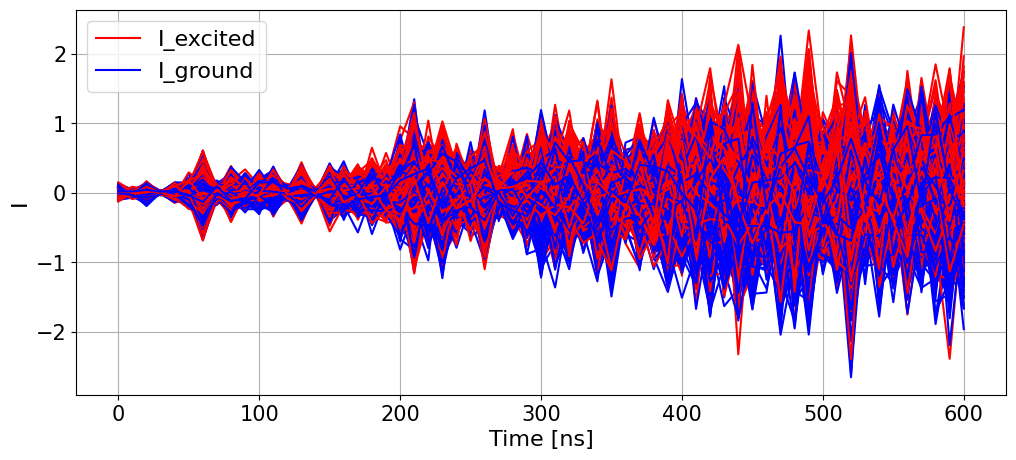

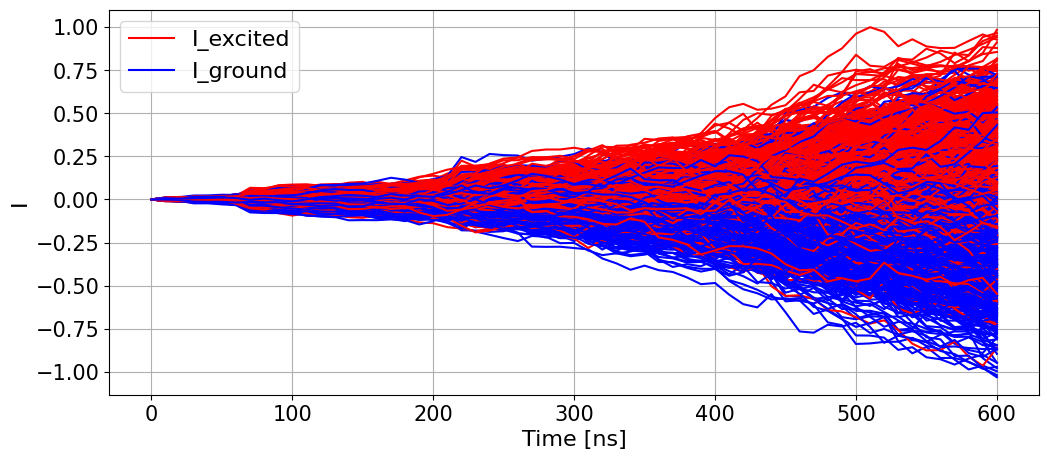

In [14]:
# plot the integrated data as a function if time
plt.figure(figsize=(12, 5))
for i, value in enumerate(I_excited):
    plt.plot(times, I_excited[i], label = 'I_excited' if i == 0 else "", color = 'red')
    plt.plot(times, I_ground[i], label = 'I_ground' if i == 0 else "", color = 'blue')
    plt.legend(fontsize = 16)
plt.xlabel("Time [ns]", size = 16)
plt.ylabel("I", size = 16)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.grid()
plt.savefig("Time_series_weighted_example.png", dpi = 600)
plt.show()

plt.figure(figsize=(12, 5))
for i, value in enumerate(I_excited):
    plt.plot(times, intI_excited[i], label = 'I_excited' if i == 0 else "", color = 'red')
    plt.plot(times, intI_ground[i], label = 'I_ground' if i == 0 else "", color = 'blue')
#plt.title("integrated ground and excited data I")
plt.legend(fontsize = 16)
plt.xlabel("Time [ns]", size = 16)
plt.ylabel("I", size = 16)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.grid()
plt.savefig("Integrated_time_series_weighted_example.png", dpi = 600)
plt.show()
#for i, value in enumerate(I_ground):
#    plt.plot(times, Q_excited[i], label = 'I_ground')
#plt.show()

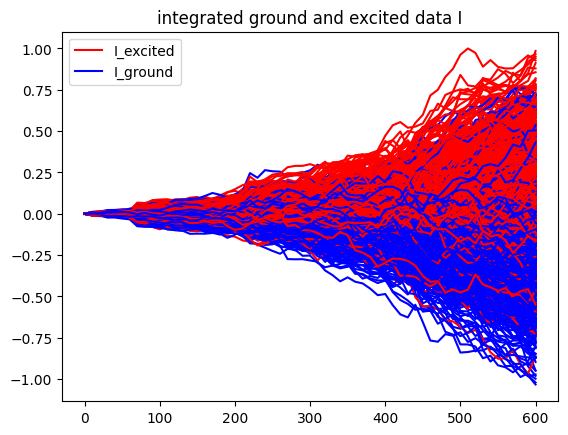

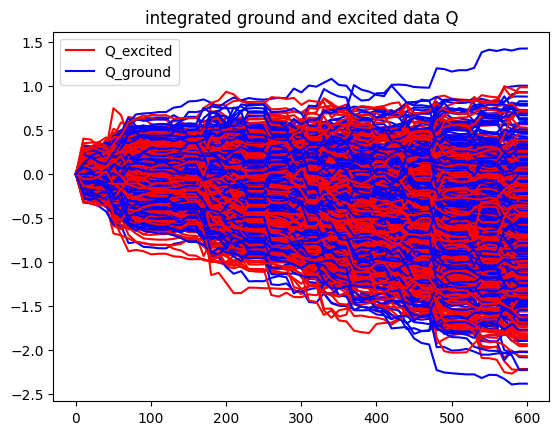

In [15]:
#Peters stuff
for i, value in enumerate(I_excited):
    plt.plot(times, intI_excited[i], label = 'I_excited' if i == 0 else '', color = 'red')
    plt.plot(times, intI_ground[i], label = 'I_ground' if i == 0 else '', color = 'blue')
plt.title("integrated ground and excited data I")
plt.legend()
plt.show()
for i, value in enumerate(I_excited):
    plt.plot(times, intQ_excited[i], label = 'Q_excited' if i == 0 else '', color = 'red')
    plt.plot(times, intQ_ground[i], label = 'Q_ground' if i == 0 else '', color = 'blue')
plt.title("integrated ground and excited data Q")
plt.legend()
plt.show()



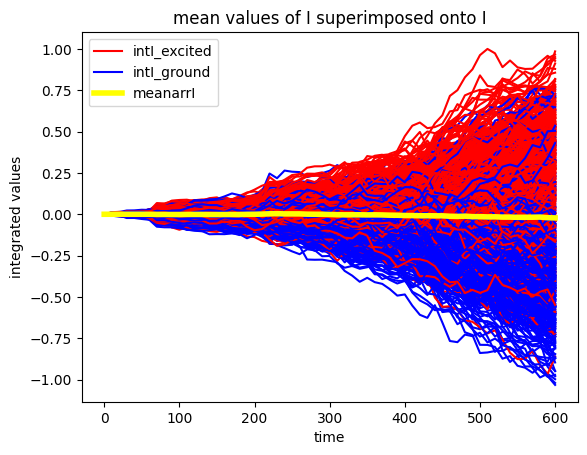

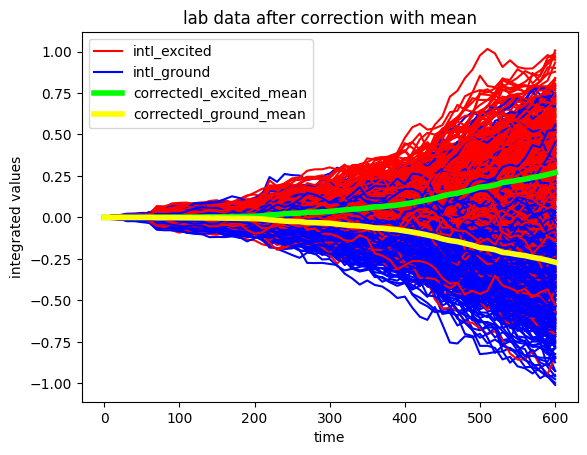

In [16]:
meanarrI = np.mean(np.concatenate((intI_excited,intI_ground), axis=0), axis=0)
for i, value in enumerate(intI_excited):
    plt.plot(times, intI_excited[i], label = 'intI_excited' if i == 0 else '', color = 'red')
    plt.plot(times, intI_ground[i], label = 'intI_ground' if i == 0 else '', color = 'blue')
    
plt.plot(times, meanarrI, label = 'meanarrI', color = 'yellow', linewidth = 4)
plt.title("mean values of I superimposed onto I")
plt.xlabel("time")
plt.ylabel("integrated values")
plt.legend()
plt.show()

correctedI_excited = intI_excited - meanarrI
correctedI_ground = intI_ground - meanarrI

correctedI_excited_mean = np.mean(correctedI_excited, axis=0)
correctedI_ground_mean = np.mean(correctedI_ground, axis=0)

for i, value in enumerate(intI_excited):
    plt.plot(times, correctedI_excited[i], label = 'intI_excited' if i == 0 else '', color = 'red')
    plt.plot(times, correctedI_ground[i], label = 'intI_ground' if i == 0 else '', color = 'blue')
plt.plot(times, correctedI_excited_mean, label = 'correctedI_excited_mean', color = 'lime', linewidth = 4)
plt.plot(times, correctedI_ground_mean, label = 'correctedI_ground_mean', color = 'yellow', linewidth = 4)
plt.title("lab data after correction with mean")
plt.xlabel("time")
plt.ylabel("integrated values")
plt.legend()
plt.show()

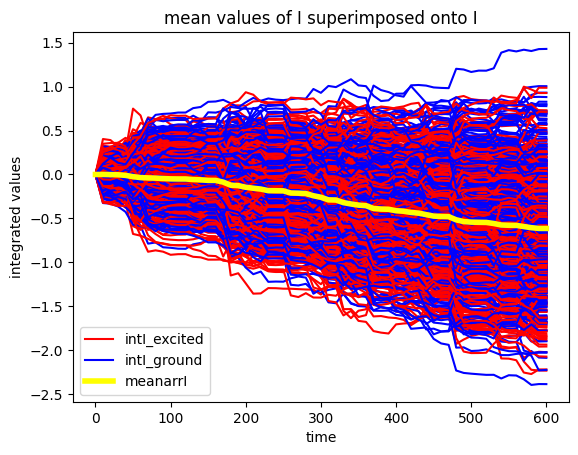

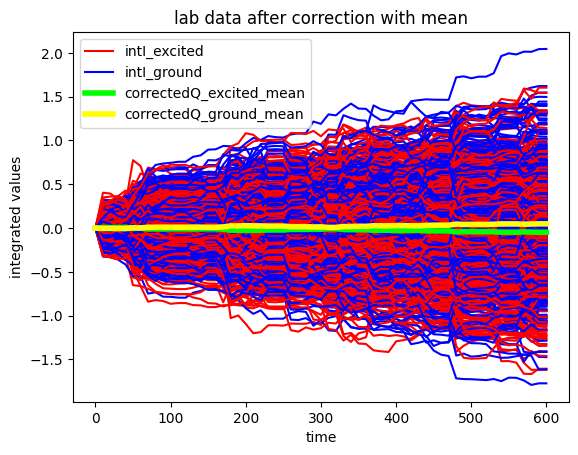

In [17]:
meanarrQ = np.mean(np.concatenate((intQ_excited,intQ_ground), axis=0), axis=0)
for i, value in enumerate(intI_excited):
    plt.plot(times, intQ_excited[i], label = 'intI_excited' if i == 0 else '', color = 'red')
    plt.plot(times, intQ_ground[i], label = 'intI_ground' if i == 0 else '', color = 'blue')
    
plt.plot(times, meanarrQ, label = 'meanarrI', color = 'yellow', linewidth = 4)
plt.title("mean values of I superimposed onto I")
plt.xlabel("time")
plt.ylabel("integrated values")
plt.legend()
plt.show()

correctedQ_excited = intQ_excited - meanarrQ
correctedQ_ground = intQ_ground - meanarrQ

correctedQ_excited_mean = np.mean(correctedQ_excited, axis=0)
correctedQ_ground_mean = np.mean(correctedQ_ground, axis=0)

for i, value in enumerate(intQ_excited):
    plt.plot(times, correctedQ_excited[i], label = 'intI_excited' if i == 0 else '', color = 'red')
    plt.plot(times, correctedQ_ground[i], label = 'intI_ground' if i == 0 else '', color = 'blue')
plt.plot(times, correctedQ_excited_mean, label = 'correctedQ_excited_mean', color = 'lime', linewidth = 4)
plt.plot(times, correctedQ_ground_mean, label = 'correctedQ_ground_mean', color = 'yellow', linewidth = 4)
plt.title("lab data after correction with mean")
plt.xlabel("time")
plt.ylabel("integrated values")
plt.legend()
plt.show()

In [18]:
## loading the real data and plotting the integation 
times_lab = ds_lab.adc_timestamp.to_numpy()
ds_lab = weighting(ds_lab)
I_excited_lab = ds_lab.I_excited.to_numpy()
I_ground_lab = ds_lab.I_ground.to_numpy()
Q_excited_lab = ds_lab.Q_excited.to_numpy()
Q_ground_lab = ds_lab.Q_ground.to_numpy()


In [19]:
#plt.plot(times_lab, I_excited_lab[0], label = 'I_excited', color = 'red')

In [20]:
label0 = np.zeros(1000)
label1 = np.ones(1000)
labels_lab = np.concatenate((label0, label1), axis = 0)

excited_lab = np.stack((I_excited_lab, Q_excited_lab), axis = 2)
ground_lab = np.stack((I_ground_lab, Q_ground_lab), axis = 2)
df_lab = np.concatenate((ground_lab, excited_lab), axis = 0)

In [21]:
labels_lab.shape

(2000,)

In [22]:
intI_excited_lab = integrate(times_lab, I_excited_lab)
max = np.max(intI_excited_lab)
intI_excited_lab = intI_excited_lab/max
intI_ground_lab = integrate(times_lab, I_ground_lab)
intI_ground_lab = intI_ground_lab/max

intQ_excited_lab = integrate(times_lab, Q_excited_lab)
max = np.max(intQ_excited_lab)
intQ_excited_lab = intQ_excited_lab/max
intQ_ground_lab = integrate(times_lab, Q_ground_lab)
intQ_ground_lab = intQ_ground_lab/max

intexcited_lab = np.stack((intI_excited_lab, intQ_excited_lab), axis = 2)
intground_lab = np.stack((intI_ground_lab, intQ_ground_lab), axis = 2)
intdf_lab = np.concatenate((intground_lab, intexcited_lab), axis = 0)

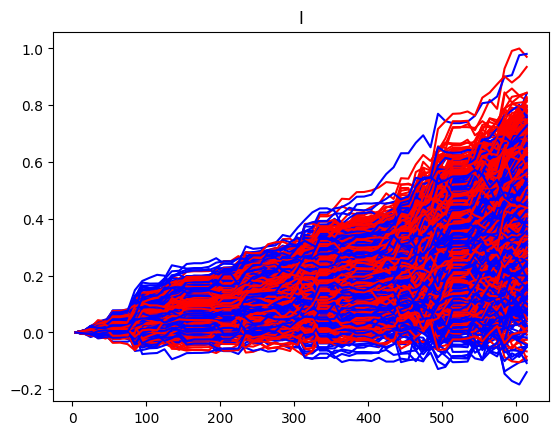

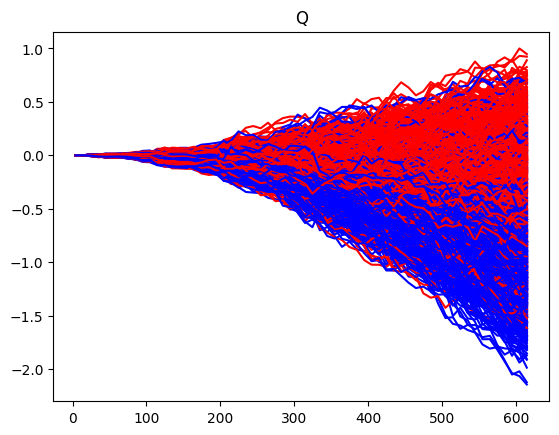

In [23]:
for i, value in enumerate(intI_excited_lab):
    plt.plot(times_lab, intI_excited_lab[i], label = 'intI_excited', color = 'red')
    plt.plot(times_lab, intI_ground_lab[i], label = 'intI_ground', color = 'blue')
#plt.legend()
plt.title("I")
plt.show()
for i, value in enumerate(intQ_excited_lab):
    plt.plot(times_lab, intQ_excited_lab[i], label = 'intI_ground', color = 'red')
    plt.plot(times_lab, intQ_ground_lab[i], label = 'intI_ground', color = 'blue')
#plt.legend()
plt.title("Q")
plt.show()

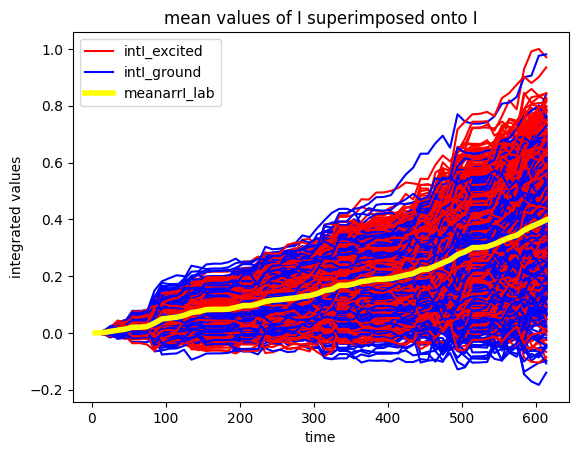

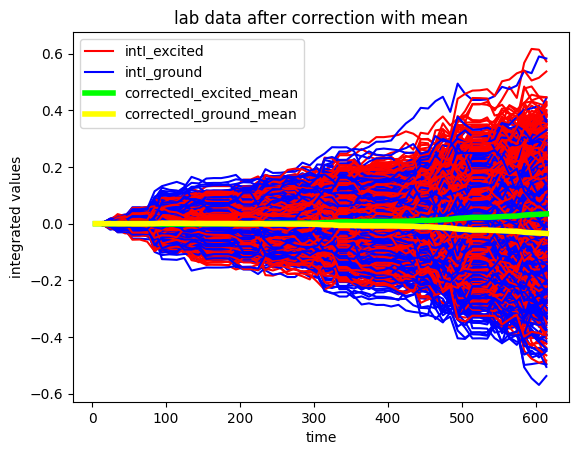

In [24]:
#Peters sektion
meanarrI = np.mean(np.concatenate((intI_excited_lab,intI_ground_lab), axis=0), axis=0)
for i, value in enumerate(intI_excited_lab):
    plt.plot(times_lab, intI_excited_lab[i], label = 'intI_excited' if i == 0 else '', color = 'red')
    plt.plot(times_lab, intI_ground_lab[i], label = 'intI_ground' if i == 0 else '', color = 'blue')

plt.plot(times_lab, meanarrI, label = 'meanarrI_lab', color = 'yellow', linewidth = 4)
plt.title("mean values of I superimposed onto I")
plt.xlabel("time")
plt.ylabel("integrated values")
plt.legend()
plt.show()

correctedI_excited_lab = intI_excited_lab - meanarrI
correctedI_ground_lab = intI_ground_lab - meanarrI

correctedI_excited_lab_mean = np.mean(correctedI_excited_lab, axis=0)
correctedI_ground_lab_mean = np.mean(correctedI_ground_lab, axis=0)

for i, value in enumerate(intI_excited_lab):
    plt.plot(times_lab, correctedI_excited_lab[i], label = 'intI_excited' if i == 0 else '', color = 'red')
    plt.plot(times_lab, correctedI_ground_lab[i], label = 'intI_ground' if i == 0 else '', color = 'blue')
plt.plot(times_lab, correctedI_excited_lab_mean, label = 'correctedI_excited_mean', color = 'lime', linewidth = 4)
plt.plot(times_lab, correctedI_ground_lab_mean, label = 'correctedI_ground_mean', color = 'yellow', linewidth = 4)
plt.title("lab data after correction with mean")
plt.xlabel("time")
plt.ylabel("integrated values")
plt.legend()
plt.show()



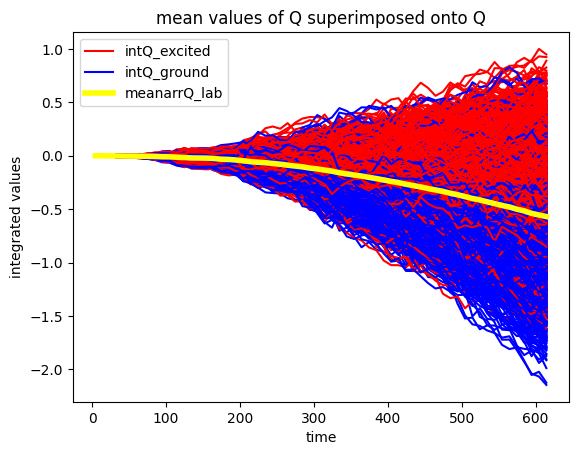

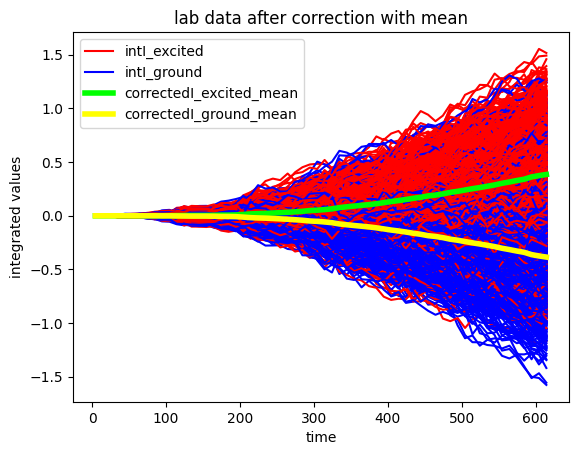

In [25]:
#Stort set det samme men for Q
meanarrQ = np.mean(np.concatenate((intQ_excited_lab,intQ_ground_lab), axis=0), axis=0)
for i, value in enumerate(intQ_excited_lab):
    plt.plot(times_lab, intQ_excited_lab[i], label = 'intQ_excited' if i == 0 else '', color = 'red')
    plt.plot(times_lab, intQ_ground_lab[i], label = 'intQ_ground' if i == 0 else '', color = 'blue')
    
plt.plot(times_lab, meanarrQ, label = 'meanarrQ_lab', color = 'yellow', linewidth = 4)
plt.title("mean values of Q superimposed onto Q")
plt.xlabel("time")
plt.ylabel("integrated values")
plt.legend()
plt.show()

correctedQ_excited_lab = intQ_excited_lab - meanarrQ
correctedQ_ground_lab = intQ_ground_lab - meanarrQ

correctedQ_excited_lab_mean = np.mean(correctedQ_excited_lab, axis=0)
correctedQ_ground_lab_mean = np.mean(correctedQ_ground_lab, axis=0)

for i, value in enumerate(intQ_excited_lab):
    plt.plot(times_lab, correctedQ_excited_lab[i], label = 'intI_excited' if i == 0 else '', color = 'red')
    plt.plot(times_lab, correctedQ_ground_lab[i], label = 'intI_ground' if i == 0 else '', color = 'blue')
plt.plot(times_lab, correctedQ_excited_lab_mean, label = 'correctedI_excited_mean', color = 'lime', linewidth = 4)
plt.plot(times_lab, correctedQ_ground_lab_mean, label = 'correctedI_ground_mean', color = 'yellow', linewidth = 4)
plt.title("lab data after correction with mean")
plt.xlabel("time")
plt.ylabel("integrated values")
plt.legend()
plt.show()

In [26]:
intexcited_sim = np.stack((intI_excited, intQ_excited), axis = 2)
intground_sim = np.stack((intI_ground, intQ_ground), axis = 2)
intdf_sim = np.concatenate((intground_sim, intexcited_sim), axis = 0)

intexcited_sim_corrected = np.stack((correctedI_excited, correctedQ_excited), axis = 2)
intground_sim_corrected = np.stack((correctedI_ground, correctedQ_ground), axis = 2)
intdf_sim_corrected = np.concatenate((intground_sim_corrected, intexcited_sim_corrected), axis = 0)

intexcited_lab = np.stack((intI_excited_lab,  intQ_excited_lab), axis = 2)
intground_lab = np.stack((intI_ground_lab, intQ_ground_lab), axis = 2)
intdf_lab = np.concatenate((intground_lab, intexcited_lab), axis = 0)

intexcited_lab_corrected = np.stack((correctedI_excited_lab,  correctedQ_excited_lab), axis = 2)
intground_lab_corrected = np.stack((correctedI_ground_lab, correctedQ_ground_lab), axis = 2)
intdf_lab_corrected = np.concatenate((intground_lab_corrected, intexcited_lab_corrected), axis = 0)

In [27]:
print(intdf_sim.shape, intdf_sim_corrected.shape, intdf_lab_corrected.shape, intdf_lab.shape)

(1000, 61, 2) (1000, 61, 2) (2000, 62, 2) (2000, 62, 2)


In [28]:
# Make a times series NN to classify the data

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, precision_recall_curve, det_curve 

from scipy.stats import norm

from sklearn.metrics import DetCurveDisplay

In [29]:
# change shape of the data for it to work with the model 
intdf_sim = intdf_sim.transpose(0, 2, 1)
intdf_sim_corrected = intdf_sim_corrected.transpose(0, 2, 1)
intdf_lab = intdf_lab.transpose(0, 2, 1)
intdf_lab_corrected = intdf_lab_corrected.transpose(0, 2, 1)

In [30]:
def data_prep_conv1d(data, labels):
    train_data, val_data,  train_labels, val_labels = train_test_split(data, labels, test_size=0.3, stratify=labels)
    #val_data, test_data, val_labels, test_labels = train_test_split(temp_data, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42)

    # Convert to PyTorch tensors
    train_data = torch.tensor(train_data, dtype=torch.float32)
    train_labels = torch.tensor(train_labels, dtype=torch.float32)
    val_data = torch.tensor(val_data, dtype=torch.float32)
    val_labels = torch.tensor(val_labels, dtype=torch.float32)
    #test_data = torch.tensor(test_data, dtype=torch.float32)
    #test_labels = torch.tensor(test_labels, dtype=torch.float32)

    train_dataset = TensorDataset(train_data, train_labels)
    val_dataset = TensorDataset(val_data, val_labels)
    #test_dataset = TensorDataset(test_data, test_labels)

    # Create DataLoaders
    batch_size = 32

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    #test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    return train_dataloader, val_dataloader#, test_dataloader

In [31]:
def train_and_val_model(train_dataloader, val_dataloader, model, criterion, optimizer, verbose = True):
    num_epochs = 70
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
       

        for i, (inputs, labels) in enumerate(train_dataloader):
            # Ensure the inputs have the correct shape
            optimizer.zero_grad()
            outputs = model(inputs)
            labels = labels.unsqueeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_train_loss = running_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)
        if verbose==True:
            print(f"Epoch [{epoch + 1}/{num_epochs}], Training loss: {running_loss / len(train_dataloader):.3f}")

        model.eval()
        val_loss = 0.0
        all_val_labels = []
        all_val_preds = []
        
        with torch.no_grad():
            for inputs, labels in val_dataloader:
                outputs = model(inputs)
                labels = labels.unsqueeze(1)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = (outputs >= 0.5).float()
                all_val_labels.extend(labels.cpu().numpy())
                all_val_preds.extend(preds.cpu().numpy())
        
        val_accuracy = accuracy_score(all_val_labels, all_val_preds)
        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        if verbose == True:
            print(f"Epoch [{epoch + 1}/{num_epochs}], Validation loss: {val_loss / len(val_dataloader):.3f}, Validation accuracy: {val_accuracy:.3f}")

    return model, train_losses, val_losses

In [32]:
def evaluate_model(model, test_dataloader, criterion, verbose = True):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_outputs = []
    
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            outputs = model(inputs)
            all_outputs.extend(outputs.cpu().numpy())
            labels = labels.unsqueeze(1)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = (outputs >= 0.5).float()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_outputs = np.array(all_outputs)
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    if verbose == True:
        print(f"Loss: {running_loss / len(test_dataloader):.3f}")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"Precision: {precision:.3f}")
        print(f"Recall: {recall:.3f}")
        print(f"F1 Score: {f1:.3f}")
    
    return all_labels, all_preds, all_outputs

In [33]:
class Conv1DNet(nn.Module):
    def __init__(self):
        super(Conv1DNet, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=8, kernel_size=3, padding=1)  # Input channels changed to 2
        self.batchnorm1 = nn.BatchNorm1d(8)
        self.conv2 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.fc1 = nn.Linear(16 * 15, 16)  # Adjust this based on your input size
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

In [34]:
def run_model(data, labels, title='Training and Validation Loss', verbose = True, plot = False):
    model = Conv1DNet()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)
    train_dataloader, val_dataloader = data_prep_conv1d(data, labels)
    model, train_losses, val_losses = train_and_val_model(train_dataloader, val_dataloader, model, criterion, optimizer, verbose)
    all_test_labels, all_test_preds, all_test_output = evaluate_model(model, val_dataloader, criterion, verbose)
    if plot == True:
        plt.figure(figsize = (12, 8))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.xlabel('Epoch', fontsize = 16)
        plt.ylabel('Loss', fontsize = 16)
        #plt.title(title)
        plt.legend(fontsize = 16)
        plt.grid()
        plt.xticks(size = 15)
        plt.yticks(size = 15)
        plt.savefig(f"{title}_sim_corrected.png", dpi = 600)
        plt.show()
    return model, all_test_labels, all_test_preds, all_test_output

Epoch [1/70], Training loss: 0.699
Epoch [1/70], Validation loss: 0.698, Validation accuracy: 0.500
Epoch [2/70], Training loss: 0.694
Epoch [2/70], Validation loss: 0.693, Validation accuracy: 0.500
Epoch [3/70], Training loss: 0.691
Epoch [3/70], Validation loss: 0.685, Validation accuracy: 0.500
Epoch [4/70], Training loss: 0.687
Epoch [4/70], Validation loss: 0.685, Validation accuracy: 0.500
Epoch [5/70], Training loss: 0.683
Epoch [5/70], Validation loss: 0.683, Validation accuracy: 0.513
Epoch [6/70], Training loss: 0.679
Epoch [6/70], Validation loss: 0.675, Validation accuracy: 0.530
Epoch [7/70], Training loss: 0.674
Epoch [7/70], Validation loss: 0.674, Validation accuracy: 0.563
Epoch [8/70], Training loss: 0.668
Epoch [8/70], Validation loss: 0.665, Validation accuracy: 0.643
Epoch [9/70], Training loss: 0.661
Epoch [9/70], Validation loss: 0.660, Validation accuracy: 0.667
Epoch [10/70], Training loss: 0.654
Epoch [10/70], Validation loss: 0.652, Validation accuracy: 0.69

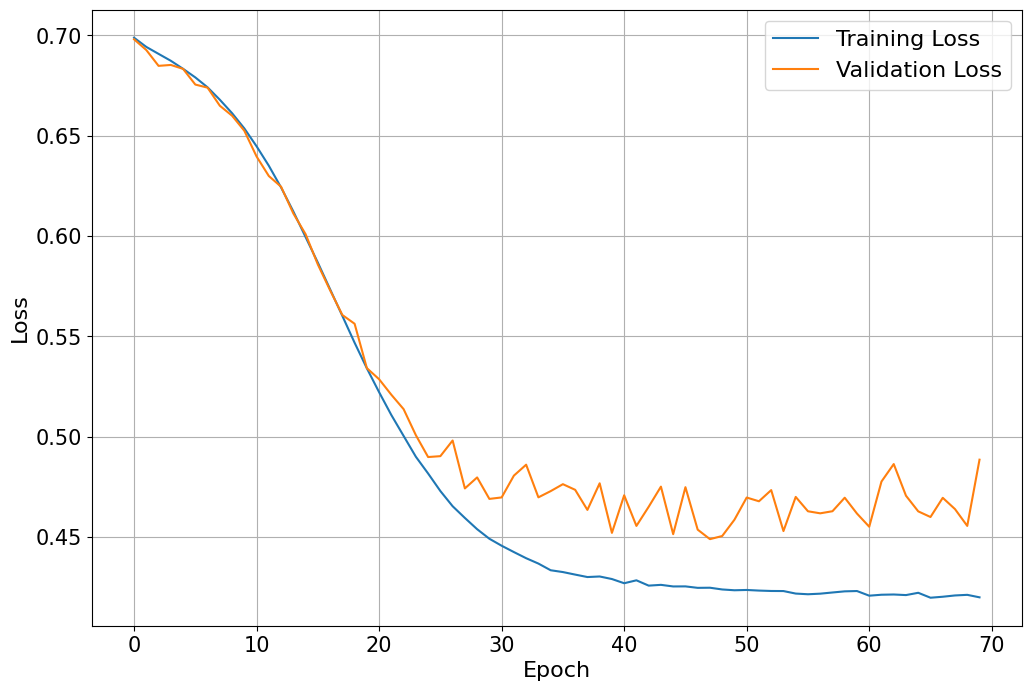

In [35]:
#Simulated data
model, all_test_labels, all_test_preds, all_test_output = run_model(intdf_sim, labels_sim, 'Training and Validation Loss, simulated data, non-corrected', plot = True)

In [36]:
def plot_det_curve(labels, predictions, plot_roc = False, plot_det = True):
    fpr, tpr, thresholds = roc_curve(labels, predictions)
    roc_auc = roc_auc_score(labels, predictions)

    fnr = 1 - tpr

    # Optionally, find the best threshold using the minimum distance to the origin
    distances = np.sqrt(fpr**2 + fnr**2)
    best_index = np.argmin(distances)

    best_threshold = thresholds[best_index]
    best_fpr = fpr[best_index]
    best_fnr = fnr[best_index]

    fidelity = 1 - best_fnr - best_fpr
    

    #print(f'Best Threshold: {best_threshold}')
    print(f'False Positive Rate at Best Threshold: {best_fpr}')
    print(f'False Negative Rate at Best Threshold: {best_fnr}')
    print(f'Fidelity: {fidelity}')
    print(f'Roc_auc score: {roc_auc}')

    if plot_roc:
        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, label='ROC Curve')
        plt.scatter(fpr[best_index], tpr[best_index], color='red', label=f'Best Threshold: {best_threshold:.2f}')
        plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
        plt.xlabel('False Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve with Best Threshold')
        plt.legend()
        plt.grid(True)
        plt.show()

    if plot_det:
        fig, ax_det = plt.subplots(figsize=(7, 5))

        # Plot DET curve
        DetCurveDisplay.from_predictions(labels, predictions, ax=ax_det, name="Classifier")

        # Set title and grid
        ax_det.set_title("Detection Error Tradeoff (DET) Curve")
        ax_det.grid(linestyle="--")

        # Show legend and plot
        plt.legend()
        plt.show()

    return fidelity

False Positive Rate at Best Threshold: 0.13333333333333333
False Negative Rate at Best Threshold: 0.21333333333333337
Fidelity: 0.6533333333333333
Roc_auc score: 0.8527111111111111


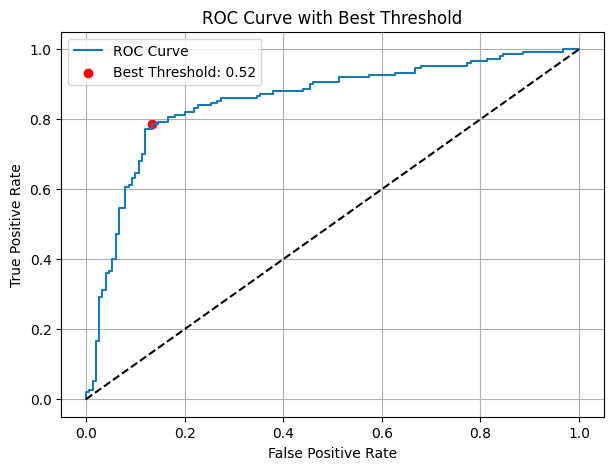

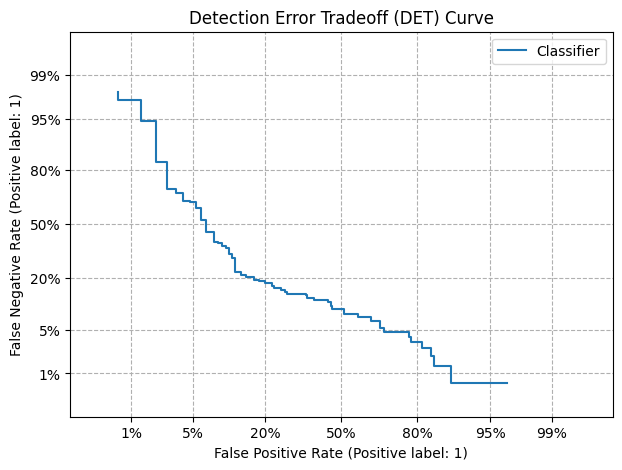

0.6533333333333333

In [37]:
plot_det_curve(all_test_labels, all_test_output, plot_roc=True, plot_det=True)

Epoch [1/70], Training loss: 0.702
Epoch [1/70], Validation loss: 0.699, Validation accuracy: 0.500
Epoch [2/70], Training loss: 0.698
Epoch [2/70], Validation loss: 0.694, Validation accuracy: 0.500
Epoch [3/70], Training loss: 0.694
Epoch [3/70], Validation loss: 0.691, Validation accuracy: 0.500
Epoch [4/70], Training loss: 0.692
Epoch [4/70], Validation loss: 0.689, Validation accuracy: 0.500
Epoch [5/70], Training loss: 0.689
Epoch [5/70], Validation loss: 0.687, Validation accuracy: 0.500
Epoch [6/70], Training loss: 0.686
Epoch [6/70], Validation loss: 0.683, Validation accuracy: 0.500
Epoch [7/70], Training loss: 0.683
Epoch [7/70], Validation loss: 0.681, Validation accuracy: 0.530
Epoch [8/70], Training loss: 0.680
Epoch [8/70], Validation loss: 0.676, Validation accuracy: 0.613
Epoch [9/70], Training loss: 0.676
Epoch [9/70], Validation loss: 0.672, Validation accuracy: 0.680
Epoch [10/70], Training loss: 0.672
Epoch [10/70], Validation loss: 0.668, Validation accuracy: 0.72

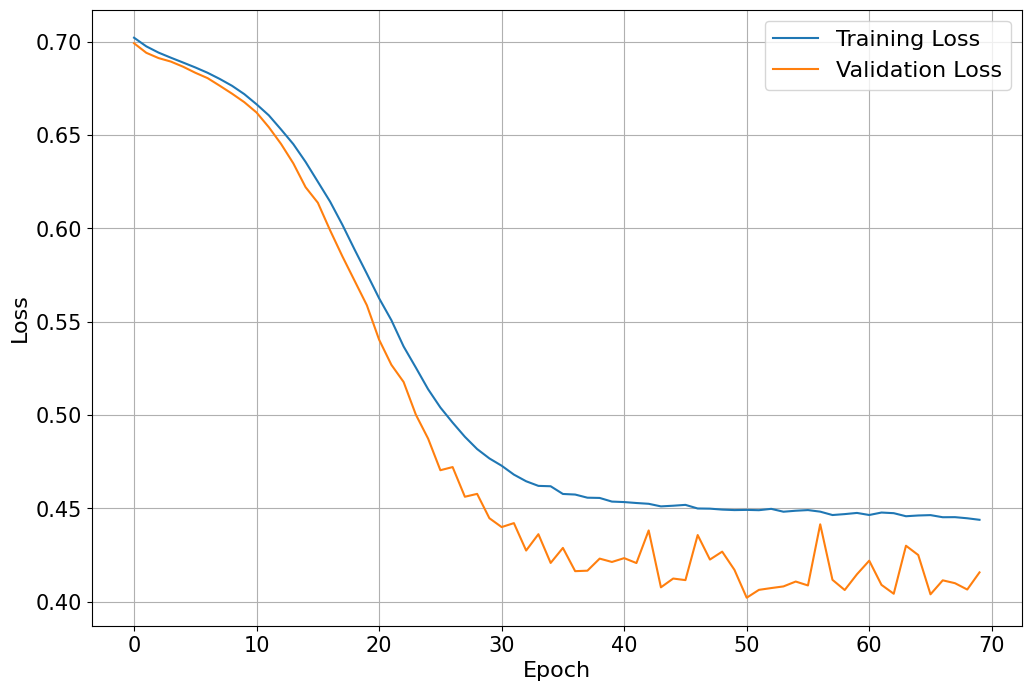

False Positive Rate at Best Threshold: 0.18666666666666668
False Negative Rate at Best Threshold: 0.1266666666666667
Fidelity: 0.6866666666666666
Roc_auc score: 0.8946222222222222


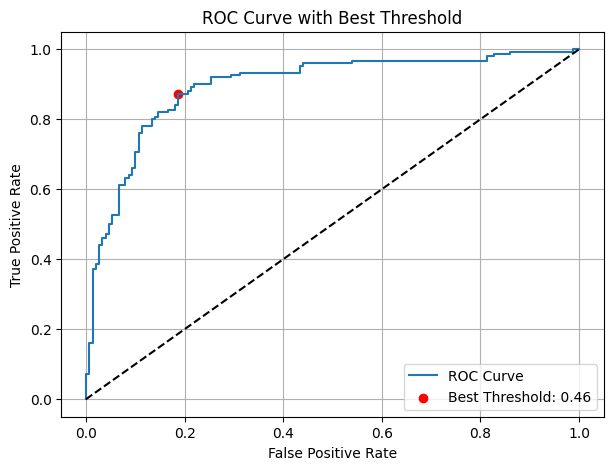

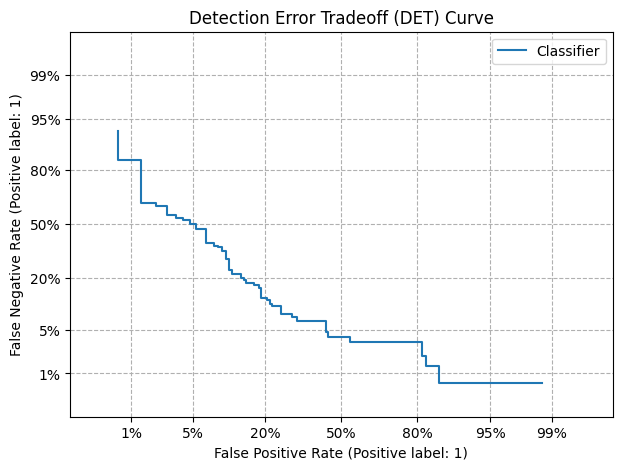

0.6866666666666666

In [38]:
#Simulated data corrected
model, all_test_labels, all_test_preds, all_test_output = run_model(intdf_sim_corrected, labels_sim, 'Training and Validation Loss, simulated data, corrected', plot = True)
plot_det_curve(all_test_labels, all_test_output, plot_roc=True, plot_det=True)

False Positive Rate at Best Threshold: 0.16333333333333333
False Negative Rate at Best Threshold: 0.23333333333333328
Fidelity: 0.6033333333333334
Roc_auc score: 0.8155777777777777


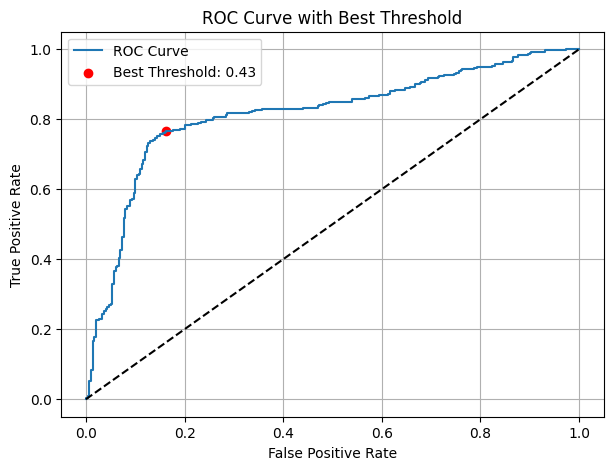

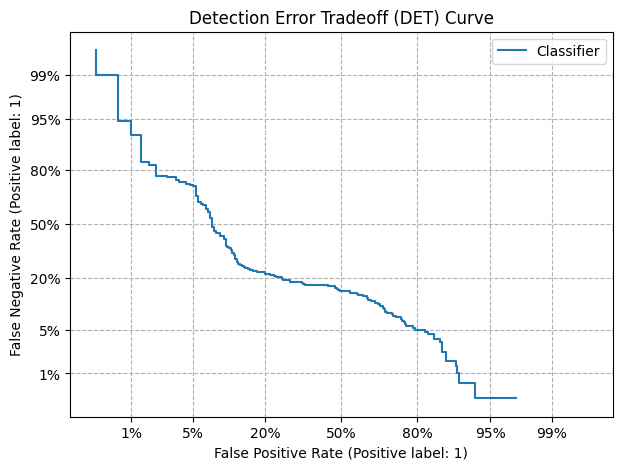

0.6033333333333334

In [39]:
#Lab data
model, all_test_labels, all_test_preds, all_test_output = run_model(intdf_lab, labels_lab, 'Training and Validation Loss, lab data, non-corrected', verbose=False)
plot_det_curve(all_test_labels, all_test_output, plot_roc=True, plot_det=True)

Epoch [1/70], Training loss: 0.700
Epoch [1/70], Validation loss: 0.695, Validation accuracy: 0.500
Epoch [2/70], Training loss: 0.692
Epoch [2/70], Validation loss: 0.689, Validation accuracy: 0.500
Epoch [3/70], Training loss: 0.686
Epoch [3/70], Validation loss: 0.680, Validation accuracy: 0.500
Epoch [4/70], Training loss: 0.676
Epoch [4/70], Validation loss: 0.669, Validation accuracy: 0.500
Epoch [5/70], Training loss: 0.664
Epoch [5/70], Validation loss: 0.653, Validation accuracy: 0.500
Epoch [6/70], Training loss: 0.647
Epoch [6/70], Validation loss: 0.633, Validation accuracy: 0.665
Epoch [7/70], Training loss: 0.627
Epoch [7/70], Validation loss: 0.612, Validation accuracy: 0.777
Epoch [8/70], Training loss: 0.605
Epoch [8/70], Validation loss: 0.586, Validation accuracy: 0.802
Epoch [9/70], Training loss: 0.581
Epoch [9/70], Validation loss: 0.560, Validation accuracy: 0.815
Epoch [10/70], Training loss: 0.558
Epoch [10/70], Validation loss: 0.536, Validation accuracy: 0.81

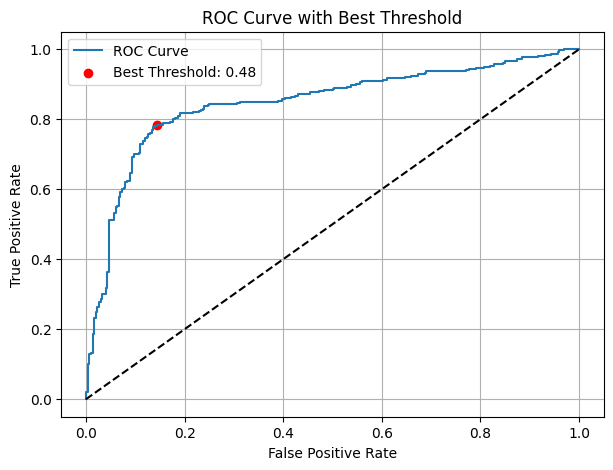

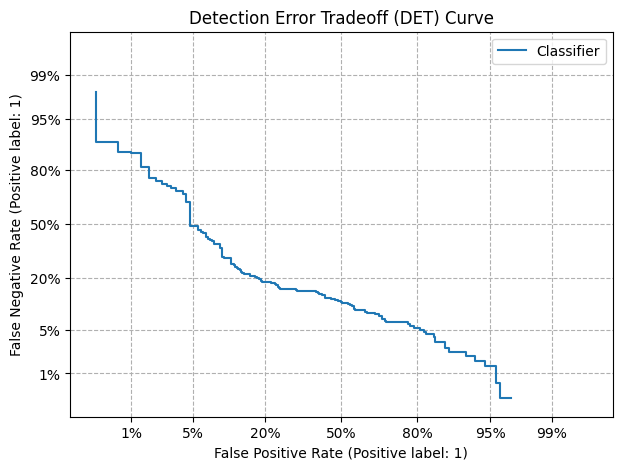

0.64

In [40]:
#Lab data corrected
model, all_test_labels, all_test_preds, all_test_output = run_model(intdf_lab_corrected, labels_lab, 'Training and Validation Loss, lab data, corrected')
plot_det_curve(all_test_labels, all_test_output, plot_roc=True, plot_det=True)

# Use cross validation

In [41]:
from sklearn.model_selection import KFold
from torchsummary import summary # used to get parameters of the model


print(intdf_lab.shape)
print(labels_lab.shape)

(2000, 2, 62)
(2000,)


In [42]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

def runfold(data_real, labels_real, kfold, batch_size, verbose=1):
    fold_results = []
    fidelity_results = []
    batch_size = batch_size
    for fold, (train_idx, val_idx) in enumerate(kfold.split(data_real)):
        if verbose>0:
            print(f'Fold {fold + 1}')

        # Split data
        train_data_real = data_real[train_idx]
        train_labels_real = labels_real[train_idx]
        val_data_real = data_real[val_idx]
        val_labels_real = labels_real[val_idx]
        if verbose>1:
            print(train_data_real.shape, train_labels_real.shape)
            print(type(train_data_real), type(train_labels_real))


        # Create DataLoader
        train_dataset_real = TensorDataset(train_data_real, train_labels_real)
        val_dataset_real = TensorDataset(val_data_real, val_labels_real)
        train_dataloader_real = DataLoader(train_dataset_real, batch_size=batch_size, shuffle=True)
        val_dataloader_real = DataLoader(val_dataset_real, batch_size=batch_size, shuffle=False)

        # Initialize model, criterion, optimizer, and scheduler
        model = Conv1DNet()
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

        # Train and validate the model
        model, train_loss, val_loss = train_and_val_model(train_dataloader_real, val_dataloader_real, model, criterion, optimizer, verbose>1)

        # Evaluate on validation data and store results
        all_val_labels = []
        all_val_preds = []

        model.eval()
        with torch.no_grad():
            for inputs, labels in val_dataloader_real:
                outputs = model(inputs)
                labels = labels.unsqueeze(1)
                preds = (outputs >= 0.5).float()
                all_val_labels.extend(labels.cpu().numpy())
                all_val_preds.extend(preds.cpu().numpy())

        val_accuracy = accuracy_score(all_val_labels, all_val_preds)
        fold_results.append(val_accuracy)
        fidelity = plot_det_curve(all_val_labels, all_val_preds, plot_roc=False, plot_det=False)
        fidelity_results.append(fidelity)
        if verbose>0:
            print(f"Fold {fold + 1}, Validation accuracy: {val_accuracy:.3f}")
    return fold_results, fidelity_results, model

In [43]:
#K-fold simulated data
data_real = torch.tensor(intdf_sim, dtype=torch.float32)
labels_real = torch.tensor(labels_sim, dtype=torch.float32)
fold_results, fidelity_results, model = runfold(data_real, labels_real, kfold, 32, 0)

False Positive Rate at Best Threshold: 0.25
False Negative Rate at Best Threshold: 0.17307692307692313
Fidelity: 0.5769230769230769
Roc_auc score: 0.7884615384615384
False Positive Rate at Best Threshold: 0.16964285714285715
False Negative Rate at Best Threshold: 0.18181818181818177
Fidelity: 0.6485389610389611
Roc_auc score: 0.8242694805194806
False Positive Rate at Best Threshold: 0.1509433962264151
False Negative Rate at Best Threshold: 0.23404255319148937
Fidelity: 0.6150140505820956
Roc_auc score: 0.8075070252910478
False Positive Rate at Best Threshold: 0.15294117647058825
False Negative Rate at Best Threshold: 0.18260869565217386
Fidelity: 0.6644501278772379
Roc_auc score: 0.8322250639386191
False Positive Rate at Best Threshold: 0.12871287128712872
False Negative Rate at Best Threshold: 0.19191919191919193
Fidelity: 0.6793679367936794
Roc_auc score: 0.8396839683968396


In [44]:
print(f'Average Validation Accuracy: {np.mean(fold_results):.3f}')
# calculate the std of the results
print(f'Standard Deviation of Validation Accuracy: {np.std(fold_results):.3f}')
print(f'Average Fidelity: {np.mean(fidelity_results):.3f}')

Average Validation Accuracy: 0.819
Standard Deviation of Validation Accuracy: 0.017
Average Fidelity: 0.637


In [45]:
#dummy_input = torch.randn(1, 2, 61)  # Adjust the batch size as needed
#output = model(dummy_input)
#print(output.shape)

input_size = (2, 61)  # Exclude the batch size
summary(model, input_size)

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv1d: 1-1                            [-1, 8, 61]               56
├─MaxPool1d: 1-2                         [-1, 8, 30]               --
├─Conv1d: 1-3                            [-1, 16, 30]              400
├─MaxPool1d: 1-4                         [-1, 16, 15]              --
├─Linear: 1-5                            [-1, 16]                  3,856
├─Linear: 1-6                            [-1, 1]                   17
├─Sigmoid: 1-7                           [-1, 1]                   --
Total params: 4,329
Trainable params: 4,329
Non-trainable params: 0
Total mult-adds (M): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.02
Estimated Total Size (MB): 0.02


Layer (type:depth-idx)                   Output Shape              Param #
├─Conv1d: 1-1                            [-1, 8, 61]               56
├─MaxPool1d: 1-2                         [-1, 8, 30]               --
├─Conv1d: 1-3                            [-1, 16, 30]              400
├─MaxPool1d: 1-4                         [-1, 16, 15]              --
├─Linear: 1-5                            [-1, 16]                  3,856
├─Linear: 1-6                            [-1, 1]                   17
├─Sigmoid: 1-7                           [-1, 1]                   --
Total params: 4,329
Trainable params: 4,329
Non-trainable params: 0
Total mult-adds (M): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.02
Estimated Total Size (MB): 0.02

In [46]:
#K-fold simulated data corrected
data_real = torch.tensor(intdf_sim_corrected, dtype=torch.float32)
labels_real = torch.tensor(labels_sim, dtype=torch.float32)
fold_results, fidelity_results, model = runfold(data_real, labels_real, kfold, 32, 0)

False Positive Rate at Best Threshold: 0.23958333333333334
False Negative Rate at Best Threshold: 0.20192307692307687
Fidelity: 0.5584935897435898
Roc_auc score: 0.7792467948717948
False Positive Rate at Best Threshold: 0.1875
False Negative Rate at Best Threshold: 0.19318181818181823
Fidelity: 0.6193181818181818
Roc_auc score: 0.8096590909090908
False Positive Rate at Best Threshold: 0.1509433962264151
False Negative Rate at Best Threshold: 0.22340425531914898
Fidelity: 0.625652348454436
Roc_auc score: 0.812826174227218
False Positive Rate at Best Threshold: 0.1411764705882353
False Negative Rate at Best Threshold: 0.18260869565217386
Fidelity: 0.6762148337595908
Roc_auc score: 0.8381074168797956
False Positive Rate at Best Threshold: 0.12871287128712872
False Negative Rate at Best Threshold: 0.19191919191919193
Fidelity: 0.6793679367936794
Roc_auc score: 0.8396839683968396


In [47]:
print(f'Average Validation Accuracy: {np.mean(fold_results):.3f}')
# calculate the std of the results
print(f'Standard Deviation of Validation Accuracy: {np.std(fold_results):.3f}')
print(f'Average Fidelity: {np.mean(fidelity_results):.3f}')
print(f'Standard Deviation of Fidelity: {np.std(fidelity_results):.3f}')
# calculate std error on the mean for the fidelity and accuracy 
print(f'Standard Error of the mean of Fidelity: {np.std(fidelity_results)/np.sqrt(5):.3f}')
print(f'Standard Error of the mean of Accuracy: {np.std(fold_results)/np.sqrt(5):.3f}')

Average Validation Accuracy: 0.816
Standard Deviation of Validation Accuracy: 0.021
Average Fidelity: 0.632
Standard Deviation of Fidelity: 0.044
Standard Error of the mean of Fidelity: 0.020
Standard Error of the mean of Accuracy: 0.010


In [48]:
input_size = (2, 61)  # Exclude the batch size
summary(model, input_size)

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv1d: 1-1                            [-1, 8, 61]               56
├─MaxPool1d: 1-2                         [-1, 8, 30]               --
├─Conv1d: 1-3                            [-1, 16, 30]              400
├─MaxPool1d: 1-4                         [-1, 16, 15]              --
├─Linear: 1-5                            [-1, 16]                  3,856
├─Linear: 1-6                            [-1, 1]                   17
├─Sigmoid: 1-7                           [-1, 1]                   --
Total params: 4,329
Trainable params: 4,329
Non-trainable params: 0
Total mult-adds (M): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.02
Estimated Total Size (MB): 0.02


Layer (type:depth-idx)                   Output Shape              Param #
├─Conv1d: 1-1                            [-1, 8, 61]               56
├─MaxPool1d: 1-2                         [-1, 8, 30]               --
├─Conv1d: 1-3                            [-1, 16, 30]              400
├─MaxPool1d: 1-4                         [-1, 16, 15]              --
├─Linear: 1-5                            [-1, 16]                  3,856
├─Linear: 1-6                            [-1, 1]                   17
├─Sigmoid: 1-7                           [-1, 1]                   --
Total params: 4,329
Trainable params: 4,329
Non-trainable params: 0
Total mult-adds (M): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.02
Estimated Total Size (MB): 0.02

In [49]:
#K-fold lab data
data_real = torch.tensor(intdf_lab, dtype=torch.float32)
labels_real = torch.tensor(labels_lab, dtype=torch.float32)
fold_results, fidelity_results, model = runfold(data_real, labels_real, kfold, 32, 0)

False Positive Rate at Best Threshold: 0.19597989949748743
False Negative Rate at Best Threshold: 0.24875621890547261
Fidelity: 0.55526388159704
Roc_auc score: 0.77763194079852
False Positive Rate at Best Threshold: 0.15196078431372548
False Negative Rate at Best Threshold: 0.22959183673469385
Fidelity: 0.6184473789515806
Roc_auc score: 0.8092236894757904
False Positive Rate at Best Threshold: 0.19339622641509435
False Negative Rate at Best Threshold: 0.20744680851063835
Fidelity: 0.5991569650742673
Roc_auc score: 0.7995784825371337
False Positive Rate at Best Threshold: 0.1625615763546798
False Negative Rate at Best Threshold: 0.2233502538071066
Fidelity: 0.6140881698382136
Roc_auc score: 0.8070440849191067
False Positive Rate at Best Threshold: 0.13736263736263737
False Negative Rate at Best Threshold: 0.22018348623853212
Fidelity: 0.6424538763988306
Roc_auc score: 0.8212269381994153


In [50]:
print(f'Average Validation Accuracy: {np.mean(fold_results):.3f}')
# calculate the std of the results
print(f'Standard Deviation of Validation Accuracy: {np.std(fold_results):.3f}')
print(f'Average Fidelity: {np.mean(fidelity_results):.3f}')

Average Validation Accuracy: 0.802
Standard Deviation of Validation Accuracy: 0.014
Average Fidelity: 0.606


In [51]:
input_size = (2, 61)  # Exclude the batch size
summary(model, input_size)

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv1d: 1-1                            [-1, 8, 61]               56
├─MaxPool1d: 1-2                         [-1, 8, 30]               --
├─Conv1d: 1-3                            [-1, 16, 30]              400
├─MaxPool1d: 1-4                         [-1, 16, 15]              --
├─Linear: 1-5                            [-1, 16]                  3,856
├─Linear: 1-6                            [-1, 1]                   17
├─Sigmoid: 1-7                           [-1, 1]                   --
Total params: 4,329
Trainable params: 4,329
Non-trainable params: 0
Total mult-adds (M): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.02
Estimated Total Size (MB): 0.02


Layer (type:depth-idx)                   Output Shape              Param #
├─Conv1d: 1-1                            [-1, 8, 61]               56
├─MaxPool1d: 1-2                         [-1, 8, 30]               --
├─Conv1d: 1-3                            [-1, 16, 30]              400
├─MaxPool1d: 1-4                         [-1, 16, 15]              --
├─Linear: 1-5                            [-1, 16]                  3,856
├─Linear: 1-6                            [-1, 1]                   17
├─Sigmoid: 1-7                           [-1, 1]                   --
Total params: 4,329
Trainable params: 4,329
Non-trainable params: 0
Total mult-adds (M): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.02
Estimated Total Size (MB): 0.02

In [52]:
#K-fold lab data corrected
data_real = torch.tensor(intdf_lab_corrected, dtype=torch.float32)
labels_real = torch.tensor(labels_lab, dtype=torch.float32)
fold_results, fidelity_results, model = runfold(data_real, labels_real, kfold, 32, 0)

False Positive Rate at Best Threshold: 0.19095477386934673
False Negative Rate at Best Threshold: 0.24875621890547261
Fidelity: 0.5602890072251807
Roc_auc score: 0.7801445036125904
False Positive Rate at Best Threshold: 0.1568627450980392
False Negative Rate at Best Threshold: 0.22959183673469385
Fidelity: 0.6135454181672669
Roc_auc score: 0.8067727090836334
False Positive Rate at Best Threshold: 0.20754716981132076
False Negative Rate at Best Threshold: 0.19148936170212771
Fidelity: 0.6009634684865515
Roc_auc score: 0.800481734243276
False Positive Rate at Best Threshold: 0.17733990147783252
False Negative Rate at Best Threshold: 0.21319796954314718
Fidelity: 0.6094621289790203
Roc_auc score: 0.8047310644895102
False Positive Rate at Best Threshold: 0.14835164835164835
False Negative Rate at Best Threshold: 0.2018348623853211
Fidelity: 0.6498134892630305
Roc_auc score: 0.8249067446315151


In [53]:
print(f'Average Validation Accuracy: {np.mean(fold_results):.3f}')
# calculate the std of the results
print(f'Standard Deviation of Validation Accuracy: {np.std(fold_results):.3f}')
print(f'Average Fidelity: {np.mean(fidelity_results):.3f}')
print(f'Standard Error of the mean of Fidelity: {np.std(fidelity_results)/np.sqrt(5):.3f}')
print(f'Standard Error of the mean of Accuracy: {np.std(fold_results)/np.sqrt(5):.3f}')

Average Validation Accuracy: 0.803
Standard Deviation of Validation Accuracy: 0.014
Average Fidelity: 0.607
Standard Error of the mean of Fidelity: 0.013
Standard Error of the mean of Accuracy: 0.006


In [54]:
input_size = (2, 61)  # Exclude the batch size
summary(model, input_size)

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv1d: 1-1                            [-1, 8, 61]               56
├─MaxPool1d: 1-2                         [-1, 8, 30]               --
├─Conv1d: 1-3                            [-1, 16, 30]              400
├─MaxPool1d: 1-4                         [-1, 16, 15]              --
├─Linear: 1-5                            [-1, 16]                  3,856
├─Linear: 1-6                            [-1, 1]                   17
├─Sigmoid: 1-7                           [-1, 1]                   --
Total params: 4,329
Trainable params: 4,329
Non-trainable params: 0
Total mult-adds (M): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.02
Estimated Total Size (MB): 0.02


Layer (type:depth-idx)                   Output Shape              Param #
├─Conv1d: 1-1                            [-1, 8, 61]               56
├─MaxPool1d: 1-2                         [-1, 8, 30]               --
├─Conv1d: 1-3                            [-1, 16, 30]              400
├─MaxPool1d: 1-4                         [-1, 16, 15]              --
├─Linear: 1-5                            [-1, 16]                  3,856
├─Linear: 1-6                            [-1, 1]                   17
├─Sigmoid: 1-7                           [-1, 1]                   --
Total params: 4,329
Trainable params: 4,329
Non-trainable params: 0
Total mult-adds (M): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.02
Estimated Total Size (MB): 0.02

In [55]:
0.029/np.sqrt(5)

0.01296919426949878

In [56]:
print(1 - (50/950) - (10/50))

0.7473684210526317


In [57]:
print(1 - (100/950) - (0/50))

0.8947368421052632
